<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<div style="text-align: center; margin-bottom: 10px;">
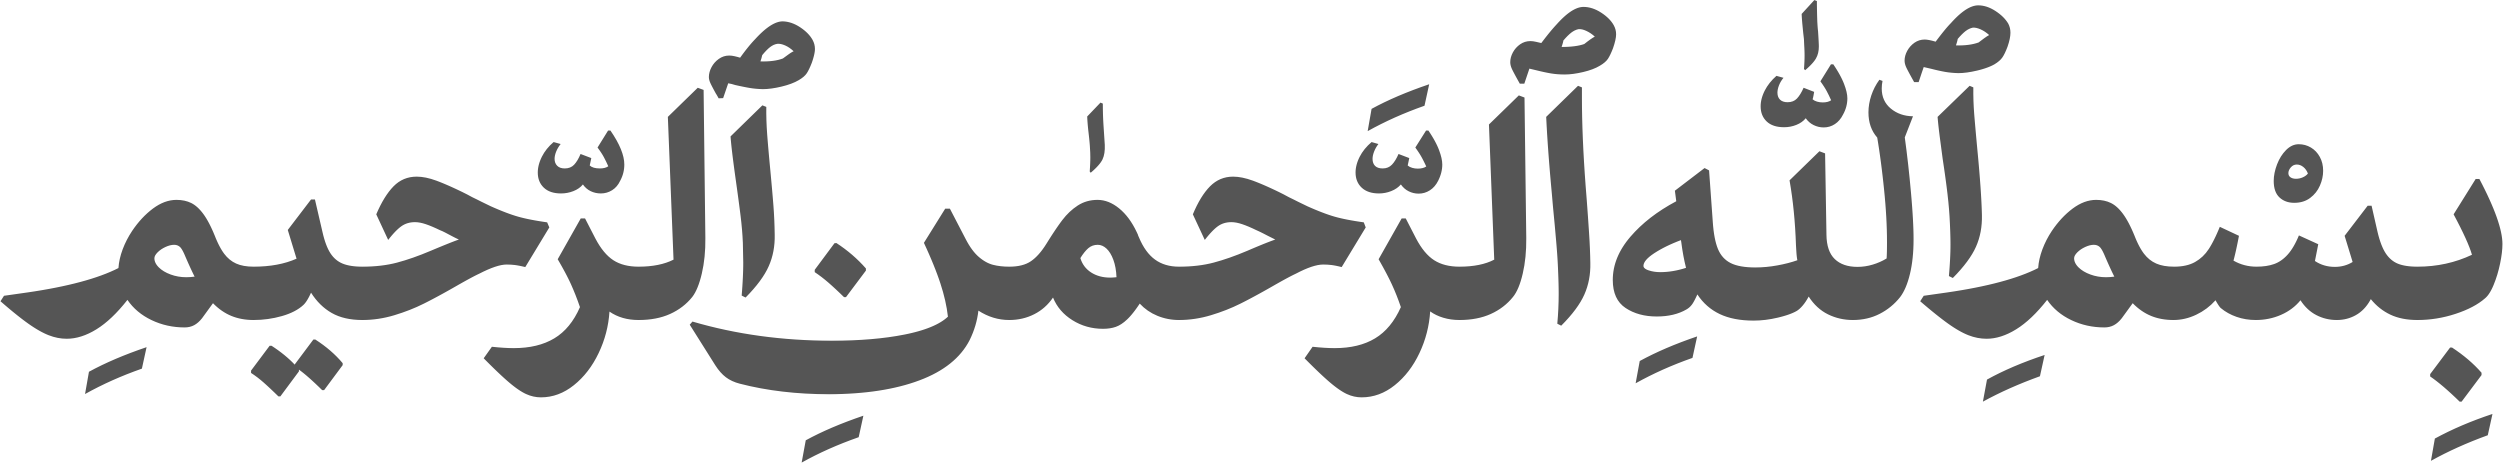
<div style="margin-top: 18px; display: flex; justify-content: center; align-items: center; gap: 30px;">
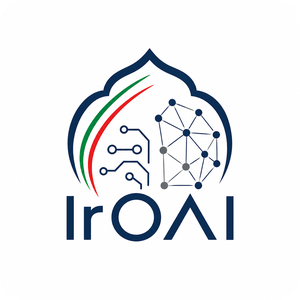
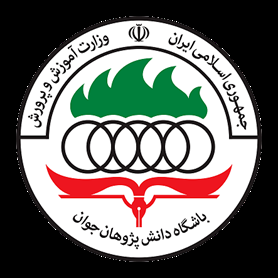
</div>
</div>
<h1 style="text-align: right; color: var(--jp-content-font-color1, #1e6bb8);">تمرین عملی المپیاد هوش مصنوعی — دوره دوم (۱۴۰۴-۱۴۰۵)</h1>
<h2 style="text-align: right; color: #3498db;">آشنایی عملی با ترنسفورمرها: از پرس‌وجوی نرم تا یک شبکه کامل برای تحلیل احساسات</h2>
<p style="text-align: right;"><b>موضوع:</b> یادگیری عمیق — ترنسفورمر (Transformer) و سازوکار توجه (Attention)</p>
<p style="text-align: right; color: var(--jp-ui-font-color2, #6b7280);">این یک تمرین آموزشی است؛ نمره‌ای از سامانه داوری دریافت نمی‌کند و هدف آن یادگیری و ساختن شهود است. در پایان، نتیجه کار خودتان را با خروجی‌های مرجع انتهای دفترچه مقایسه کنید.</p>
</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۰ — مقدمه</h2>
<p style="text-align: right;">
شبکه‌های بازگشتی (RNN) متن را به‌صورت دنباله‌ای و گام‌به‌گام پردازش می‌کنند؛ هر گام به خروجی گام قبلی وابسته است، بنابراین انتقال اطلاعات بین جایگاه‌های دور متن از یک گلوگاه عبور می‌کند و موازی‌سازی هم دشوار است. سازوکار توجه (Attention) این محدودیت را برطرف می‌کند: هر نشانه (token) می‌تواند به‌طور مستقیم و به‌صورت موازی به <b>همه</b> نشانه‌های دیگر «توجه» کند و اطلاعات مورد نیازش را از میان آن‌ها جمع کند.
</p>
<p style="text-align: right;">
هدف نهایی این دفترچه از همین ابتدا روشن است: تا انتهای آن، شما یک <b>کدگذار ترنسفورمر کوچک را از صفر می‌سازید</b> و آن را برای طبقه‌بندی احساسات نظرات IMDb (مثبت/منفی) آموزش می‌دهید. در مسیر، هر قطعه را مرحله‌به‌مرحله می‌سازید، رفتار آن را به‌صورت تصویری بررسی می‌کنید و در پایان، توجه مدل <b>واقعی و آموزش‌دیده</b> خودتان را روی نظرات واقعی می‌بینید.
</p>
<p style="text-align: right; color: var(--jp-ui-font-color2, #6b7280);">
ابزارها: فقط PyTorch، NumPy و Matplotlib — هیچ کتابخانهٔ شبکه عصبی دیگری استفاده نمی‌شود.
</p>
</div>

In [1]:
# Setup - read-only cell; do not edit
import math
import pickle
import random
import re
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import torch
import torch.nn as nn

%matplotlib inline

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DATA_DIR = Path("data")
IMDB_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
PAD_IDX = 0
UNK_IDX = 1

print("setup ok | torch", torch.__version__)

setup ok | torch 2.8.0+cpu


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۱ — پرس‌وجوی نرم (Soft Querying)</h2>
<p style="text-align: right;">
ایدهٔ اصلی توجه با یک استعارهٔ ساده شروع می‌شود: حافظه‌ای داریم از <code dir="ltr">n</code> جفت «کلید/مقدار» (key/value) و یک <b>پرس‌وجو</b> (query) می‌رسد. پرس‌وجو با هر کلید مقایسه می‌شود، به کلیدهای شبیه‌تر وزن بیشتری می‌دهیم و پاسخ، میانگین وزنیِ مقدارهاست.
</p>
<p style="text-align: right;">
شباهت پرس‌وجو <code dir="ltr">q</code> با کلید <code dir="ltr">k_i</code> را با ضرب نقطه‌ای می‌سنجیم: $s_i = q \cdot k_i$. سپس این امتیازها را با <b>سافتمکس</b> به وزن‌های نرمال‌شده تبدیل می‌کنیم: $w_i = \frac{e^{s_i}}{\sum_j e^{s_j}}$، و خروجی، جمع وزنیِ مقدارهاست: $c = \sum_i w_i v_i$.
</p>
<p style="text-align: right;">
به این کار «پرس‌وجوی نرم» می‌گوییم، چون برخلاف بازیابی سخت (argmax)، <b>همه</b> مقدارها با وزن‌های مثبت در خروجی سهم دارند و وزن‌ها فقط مشخص می‌کنند «چقدر». این نرمی همان چیزی است که به مدل اجازه می‌دهد به‌صورت مشتق‌پذیر یاد بگیرد.
</p>
<h3 style="text-align: right;">نمونهٔ دست‌ساز: چهار میوه</h3>
<p style="text-align: right;">
چهار میوه با بردار ویژگی‌های (شیرین، زرد، ترش، گرد) داده شده‌اند (سلول بعدی):
</p>
<ul style="text-align: right;">
<li style="text-align: right;"><code dir="ltr">apple</code>: [1, 0, 0, 1] — شیرین و گرد</li>
<li style="text-align: right;"><code dir="ltr">banana</code>: [0, 1, 0, 1] — زرد و گرد</li>
<li style="text-align: right;"><code dir="ltr">lemon</code>: [0, 1, 1, 0] — زرد و ترش</li>
<li style="text-align: right;"><code dir="ltr">grape</code>: [1, 0, 1, 0] — شیرین و ترش</li>
</ul>
<p style="text-align: right;">
کلیدها و مقدارها هر دو همین بردارها هستند (خودتوجهی). برای پرس‌وجوی «لیمویی» یعنی <code dir="ltr">q = [0, 1, 1, 0]</code>، ضرب‌های نقطه‌ای برابر 0، 1، 2 و 1 می‌شوند و با $e \approx 2.72$ می‌توانید وزن‌ها را با دست حساب کنید: $w \approx [0.07,\ 0.20,\ 0.53,\ 0.20]$. یعنی خروجی باید عمدتاً «زرد و ترش» باشد — همان لیمو. برای پرس‌وجوی «سیبی» یعنی <code dir="ltr">q = [1, 0, 0, 1]</code> نیز وزن‌ها تقریباً $[0.53,\ 0.20,\ 0.07,\ 0.20]$ می‌شوند.
</p>
<h3 style="text-align: right;">وظیفه</h3>
<p style="text-align: right;">
تابع <code dir="ltr">soft_query(query, keys, values)</code> را با <code dir="ltr">numpy</code> پیاده‌سازی کنید که بردار وزن‌ها و بردار زمینه (context) را برمی‌گرداند. سپس برای هر دو پرس‌وجوی داده‌شده، وزن‌ها و زمینه را چاپ کنید و <b>نمودار میله‌ای وزن‌ها را برای هر دو پرس‌وجو کنار هم</b> رسم کنید تا تفاوت «نرم» با «سخت» (یک‌داغ) کاملاً دیده شود.
</p>
</div>

In [2]:
# Given toy data - read-only cell; do not edit.
# 4 fruits described by 4 features: [sweet, yellow, sour, round]
FRUITS = ["apple", "banana", "lemon", "grape"]
V = np.array([
    [1, 0, 0, 1],   # apple : sweet, round
    [0, 1, 0, 1],   # banana: yellow, round
    [0, 1, 1, 0],   # lemon : yellow, sour
    [1, 0, 1, 0],   # grape : sweet, sour
], dtype=float)
QUERIES = {
    "lemon": np.array([0, 1, 1, 0], dtype=float),   # "a yellow, sour fruit"
    "apple": np.array([1, 0, 0, 1], dtype=float),   # "a sweet, round fruit"
}
print("keys/values (4 fruits, d = 4):")
print(V)
print("queries:")
for name, q in QUERIES.items():
    print(f"  {name}: {q}")

keys/values (4 fruits, d = 4):
[[1. 0. 0. 1.]
 [0. 1. 0. 1.]
 [0. 1. 1. 0.]
 [1. 0. 1. 0.]]
queries:
  lemon: [0. 1. 1. 0.]
  apple: [1. 0. 0. 1.]


query 'lemon': weights [0.072 0.197 0.534 0.197] | context [0.269 0.731 0.731 0.269]
query 'apple': weights [0.534 0.197 0.072 0.197] | context [0.731 0.269 0.269 0.731]


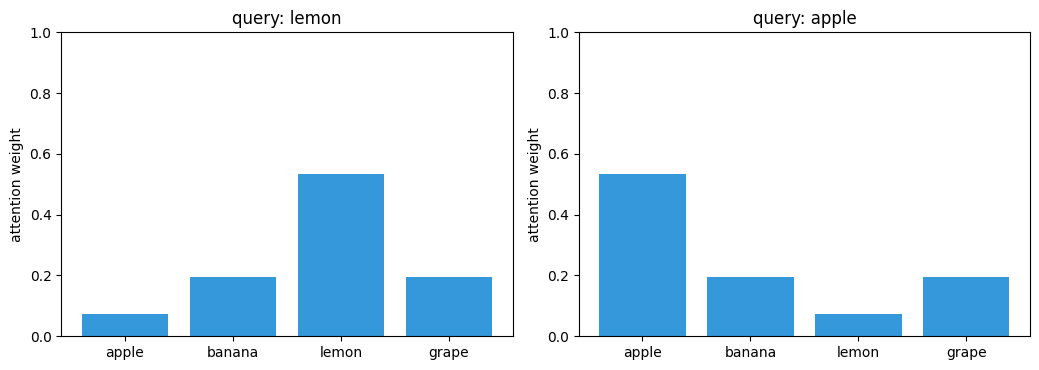

In [3]:
# TODO: implement 'soft_query(query, keys, values)' with numpy:
#       - scores:   dot products query . key_i, shape (n_keys,)
#       - weights:  softmax of the scores
#       - context:  weighted sum of the values
#       return (weights, context)
# TODO: for both query vectors from the given cell, print the weights and the
#       context, and plot a bar chart of the weights side by side
#       (two subplots; this is the "soft retrieval" picture)


def soft_query(query, keys, values):
    scores = keys @ query
    weights = np.exp(scores - scores.max()) / np.exp(scores - scores.max()).sum()
    context = weights @ values
    return weights, context


fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for ax, (name, q) in zip(axes, QUERIES.items()):
    w, c = soft_query(q, V, V)
    print(f"query '{name}': weights {w.round(3)} | context {c.round(3)}")
    ax.bar(FRUITS, w, color="#3498db")
    ax.set_title(f"query: {name}")
    ax.set_ylabel("attention weight")
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۲ — توجه ضرب‌نقطه‌ای مقیاس‌شده (Scaled Dot-Product Attention)</h2>
<p style="text-align: right;">
حالا به‌جای یک پرس‌وجو، کل دنباله را پرس‌وجو می‌کنیم: در <b>خودتوجهی</b> هر نشانه هم‌زمان نقش پرس‌وجو، کلید و مقدار را دارد. اگر همهٔ پرس‌وجوها را در ماتریس <code dir="ltr">Q</code>، کلیدها را در <code dir="ltr">K</code> و مقدارها را در <code dir="ltr">V</code> بچینیم، همهٔ توجه‌ها یک‌جا و به‌صورت ماتریسی حساب می‌شوند:
</p>
$$ \mathrm{Attention}(Q, K, V) = \mathrm{softmax}\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V $$
<p style="text-align: right;">
چرا تقسیم بر $\sqrt{d_k}$؟ اگر مؤلفه‌های <code dir="ltr">q</code> و <code dir="ltr">k</code> واریانس محدودی داشته باشند، هر ضرب نقطه‌ای $q \cdot k$ واریانسی حدود $d_k$ دارد؛ با بزرگ‌تر شدن $d_k$ امتیازها «بلند» می‌شوند و سافتمکس وارد حالت اشباع (نزدیک به یک‌داغ) می‌شود: وزن‌ها دیگر «نرم» نیستند و گرادیان‌ها عملاً می‌میرند. تقسیم بر $\sqrt{d_k}$ واریانس امتیازها را به حدود ۱ برمی‌گرداند.
</p>
<p style="text-align: right;">
این را به‌صورت تجربی هم نشان می‌دهیم: جملهٔ نمونهٔ «the cat sat on the mat» (۶ نشانه) را با یک ماتریس <code dir="ltr">embedding</code> ثابت (سیددار) به بعد $d_{model} = 32$ می‌بریم. برای اینکه برآورد واریانس با قطرِ خودتوجهی اریب نشود، <code dir="ltr">Q</code> را یک بردارسازیِ جدا (با همان سید) و $K = V$ را همان بردارسازی اول می‌گیریم — در خودتوجهیِ واقعیِ فازهای بعد، هر سه از یک ورودی ساخته می‌شوند. امتیازهای خام (بدون مقیاس) و مقیاس‌شده را با هم مقایسه می‌کنیم و گرمای (heatmap) توجه هر دو حالت را رسم می‌کنیم؛ می‌بینید که بدون مقیاس‌بندی، هر ردیف تقریباً یک‌داغ می‌شود.
</p>
<h3 style="text-align: right;">ماسک علّی (Causal Mask)</h3>
<p style="text-align: right;">
تابع شما یک پارامتر اختیاری <code dir="ltr">mask</code> هم خواهد داشت. در یک مدل زبانی <b>کدگشا</b> (decoder-only)، نشانهٔ <code dir="ltr">i</code> فقط باید به نشانه‌های جایگاه‌های $\le i$ «نگاه» کند وگرنه آینده را می‌بیند؛ چنین ماسکی مثلثی است. در معماری <b>فقط-کدگذار</b> این دفترچه از این ماسک استفاده نمی‌کنیم، اما پیاده‌سازی آن تمرین خوبی است و در «بحث کنید» به تفاوت این دو برمی‌گردیم.
</p>
<h3 style="text-align: right;">وظیفه</h3>
<p style="text-align: right;">
تابع <code dir="ltr">scaled_dot_product_attention(Q, K, V, mask=None)</code> را با PyTorch بنویسید که زوج <code dir="ltr">(out, weights)</code> را برمی‌گرداند. تابع کمکی <code dir="ltr">causal_mask(n)</code> را هم بنویسید که یک ماسک مثلثی <code dir="ltr">(n, n)</code> از جنس <code dir="ltr">bool</code> برمی‌گرداند؛ در مکان‌های <code dir="ltr">True</code> امتیاز باید با $-\infty$ جایگزین شود تا وزن سافتمکس آن صفر شود.
</p>
<p style="text-align: right;">
سپس در سلول بعدی: واریانس امتیازهای خام و مقیاس‌شده و بیشینهٔ وزن سافتمکس هر دو حالت را چاپ کنید، گرمای توجه هر دو حالت را با برچسب واقعی نشانه‌ها روی <b>هر دو محور</b> رسم کنید و با <code dir="ltr">causal_mask</code> روی جملهٔ نمونه بازی کنید تا نتیجهٔ آن را ببینید.
</p>
</div>

In [4]:
# Given toy data - read-only cell; do not edit.
# A 6-token sentence with fixed (seeded) random "embeddings" of dimension 32.
# K = V use one seeded draw; Q uses a SEPARATE seeded draw, so that the logits
# Q @ K^T are dot products of independent vectors and the effect of the 1/sqrt(d_k)
# scaling can be measured without the self-attention diagonal biasing it.
TOY_SENTENCE = ["the", "cat", "sat", "on", "the", "mat"]
D_MODEL_TOY = 32
_rng0 = np.random.RandomState(0)
E_toy = _rng0.randn(len(TOY_SENTENCE), D_MODEL_TOY).astype(np.float32)
Q_toy = _rng0.randn(len(TOY_SENTENCE), D_MODEL_TOY).astype(np.float32)
print("toy sentence:", TOY_SENTENCE)
print("toy embedding matrix shapes:", E_toy.shape, Q_toy.shape)

toy sentence: ['the', 'cat', 'sat', 'on', 'the', 'mat']
toy embedding matrix shapes: (6, 32) (6, 32)


In [5]:
# TODO: implement 'scaled_dot_product_attention(Q, K, V, mask=None)'
#       which returns (out, weights):
#           scores = Q @ K^T / sqrt(d_k),  weights = softmax(scores, dim=-1),
#           out = weights @ V
#       mask (optional): bool tensor broadcastable to (..., T, T); the logits
#       at True positions are set to -inf so their softmax weight becomes 0
# TODO: implement 'causal_mask(n)' -> (n, n) bool tensor, True above the diagonal


def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))
    weights = torch.softmax(scores, dim=-1)
    out = torch.matmul(weights, V)
    return out, weights


def causal_mask(n):
    rows = torch.arange(n).unsqueeze(1)
    cols = torch.arange(n).unsqueeze(0)
    return rows > cols

d_k = 32
variance of raw logits:      28.443   (about d_k = 32)
variance of scaled logits:    0.889   (about 1)
max softmax weight (raw):    0.993
max softmax weight (scaled): 0.461


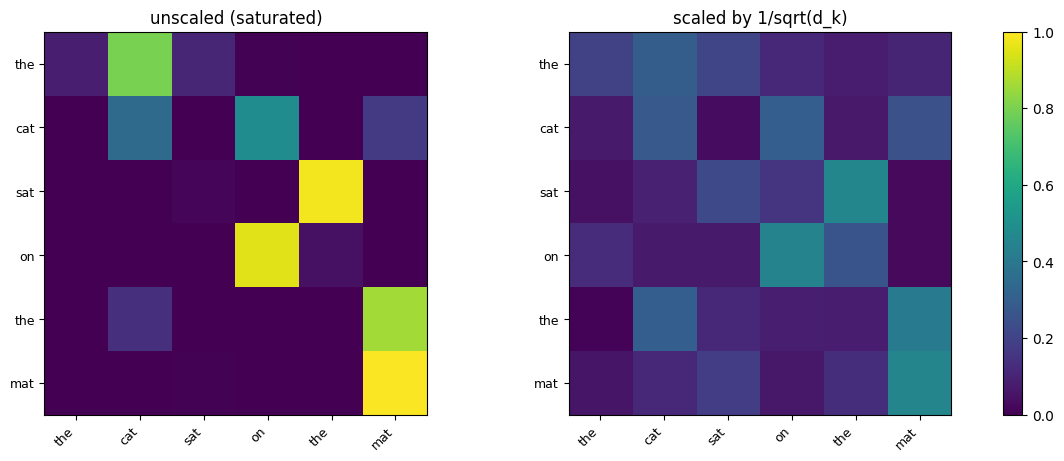

causal mask (True = hidden from the future):
[[False False False False False False]
 [ True False False False False False]
 [ True  True False False False False]
 [ True  True  True False False False]
 [ True  True  True  True False False]
 [ True  True  True  True  True False]]
attention weights of the last token with causal mask:
[0. 0. 0. 0. 0. 1.]


In [6]:
# TODO: compute the raw scores (Q @ K^T, no scaling) and the scaled ones
# TODO: print the variance of the logits in both cases and the max softmax
#       weight in both cases (you will see saturation without scaling)
# TODO: plot the two attention heatmaps side by side (imshow) with the actual
#       tokens as labels on both axes
# TODO: re-run the toy attention with 'causal_mask' and print the weights of
#       the last token (it may only attend to itself and the earlier tokens)

Q = torch.tensor(Q_toy)                      # queries (separate draw, see the given cell)
K = V = torch.tensor(E_toy)                  # keys and values over the toy sentence

raw_scores = torch.matmul(Q, K.transpose(-2, -1))
scaled_scores = raw_scores / math.sqrt(Q.shape[-1])

w_raw = torch.softmax(raw_scores, dim=-1)
w_scaled = torch.softmax(scaled_scores, dim=-1)

print(f"d_k = {Q.shape[-1]}")
print(f"variance of raw logits:    {raw_scores.var().item():8.3f}   (about d_k = {Q.shape[-1]})")
print(f"variance of scaled logits: {scaled_scores.var().item():8.3f}   (about 1)")
print(f"max softmax weight (raw):    {w_raw.max().item():.3f}")
print(f"max softmax weight (scaled): {w_scaled.max().item():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5), layout="constrained")
for ax, W, title in [(axes[0], w_raw.numpy(), "unscaled (saturated)"),
                     (axes[1], w_scaled.numpy(), "scaled by 1/sqrt(d_k)")]:
    im = ax.imshow(W, cmap="viridis", vmin=0.0, vmax=1.0)
    ax.set_xticks(range(len(TOY_SENTENCE)), TOY_SENTENCE, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(TOY_SENTENCE)), TOY_SENTENCE, fontsize=9)
    ax.set_title(title)
fig.colorbar(im, ax=axes, fraction=0.03)
plt.show()

mask = causal_mask(len(TOY_SENTENCE))
_, w_masked = scaled_dot_product_attention(Q, K, V, mask=mask)
print("causal mask (True = hidden from the future):")
print(mask.numpy())
print("attention weights of the last token with causal mask:")
print(np.round(w_masked[-1].numpy(), 3))

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right; color: #3498db;">بحث کنید</h3><p style="text-align: right;">چرا مقیاس‌بندی با جذر $d_k$ لازم است؟ اگر حذفش کنیم چه اتفاقی می‌افتد؟ (نکته: به نمودار اشباع و واریانس امتیازها نگاه کنید.)</p><p style="text-align: right;"><b>پاسخ پیشنهادی (برای مقایسه با پاسخ خودتان):</b></p><p style="text-align: right;">ضرب نقطه‌ای دو بردار با بعد $d_k$ و مؤلفه‌های مستقل با واریانس محدود، واریانسی حدود $d_k$ دارد؛ پس با بزرگ‌تر شدن $d_k$ امتیازها بلند می‌شوند و سافتمکس آن‌ها را به وزن‌های تقریباً یک‌داغ تبدیل می‌کند. در اجرای همین دفترچه دیدیم که بدون مقیاس، واریانس امتیازها حدود ۲۸ بود (یعنی تقریباً $d_k = 32$) و بیشینهٔ وزن سافتمکس به ۰٫۹۹۳ رسید؛ با تقسیم بر جذر $d_k$ واریانس به حدود ۰٫۹ افتاد و بیشینهٔ وزن شد ۰٫۴۶۱ — یعنی وزن‌ها واقعاً نرم ماندند. اگر مقیاس‌بندی را حذف کنیم، در عمق‌های بیشتر گرادیان سافتمکس در ناحیهٔ اشباع تقریباً صفر می‌شود (وقتی یک ورودی کاملاً مسلط است) و توجه عملاً به انتخاب سخت (argmax) تبدیل می‌شود. نکتهٔ تکمیلی: در خودتوجهی، قطر ماتریس $QK^T$ ذاتاً بزرگ است (ضرب هر بردار در خودش)؛ به همین دلیل در آزمایش فاز ۲، پرس‌وجوها را مستقل از کلیدها ساختیم تا اثر خالص مقیاس‌بندی دیده شود.</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۳ — توجه چندسر (Multi-Head Attention)</h2>
<p style="text-align: right;">
یک ماتریس توجه می‌تواند فقط «یک نوع» رابطه را دنبال کند. در <b>توجه چندسر</b>، به‌جای یک نگاشت $Q, K, V$ بزرگ، بعد مدل را بین چند «سر» کوچک تقسیم می‌کنیم و هر سر به‌صورت موازی توجه خودش را محاسبه می‌کند؛ سپس خروجی سرها کنار هم چیده و با یک نگاشت خطی ترکیب می‌شود. به این ترتیب هر سر می‌تواند در یک نوع رابطه تخصص بگیرد — مثلاً یکی روابط نحوی (فاعل/فعل)، یکی مرجع‌دانیِ ضمایر (coreference) و یکی الگوهای جایگاهی را دنبال کند.
</p>
<p style="text-align: right;">
اتفاقاً این دقیقاً همان چیزی است که در مدل‌های بزرگ (مانند GPT و BERT) مشاهده شده است. در مقیاس کوچک این دفترچه هم بعضی سرها ساختار پیدا می‌کنند و بعضی نویزی می‌مانند — این طبیعی است و خودش یک «بحث کنید» است.
</p>
<h3 style="text-align: right;">اعداد دقیق مدل این دفترچه (از اینجا به بعد همه‌جا استفاده می‌شود)</h3>
<ul style="text-align: right;">
<li style="text-align: right;">$d_{model} = 64$</li>
<li style="text-align: right;">$n_{heads} = 4$</li>
<li style="text-align: right;">پس $d_k = d_v = d_{model} / n_{heads} = 16$</li>
</ul>
<p style="text-align: right;">
این اعداد در سلول دادهٔ بعدی به‌صورت ثابت‌ها (constants) تعریف شده‌اند و بقیهٔ فازها از همان‌ها استفاده می‌کنند.
</p>
<h3 style="text-align: right;">ساختار ماژول</h3>
<p style="text-align: right;">
نگاشت‌های خطی <code dir="ltr">Wq</code>، <code dir="ltr">Wk</code> و <code dir="ltr">Wv</code> ورودی <code dir="ltr">(B, T, 64)</code> را به هم‌اندازهٔ خودش می‌برند؛ سپس هر کدام به شکل <code dir="ltr">(B, n_heads, T, d_k)</code> بازآرایی می‌شوند، توجهِ فاز ۲ روی هر سر جدا اعمال می‌شود و در پایان خروجی سرها به هم می‌چسبند (concat) و از <code dir="ltr">Wo</code> می‌گذرند.
</p>
<h3 style="text-align: right;">وظیفه</h3>
<p style="text-align: right;">
ماژول <code dir="ltr">MultiHeadAttention(nn.Module)</code> را با یک <code dir="ltr">assert d_model % n_heads == 0</code> در ابتدای سازنده پیاده‌سازی کنید. این فاز نمودار ندارد؛ تصویرسازی چندسرِ واقعی، بعد از آموزش مدل در فاز ۷ و با همین ماژول انجام می‌شود.
</p>
</div>

In [7]:
# Given config (phase 3) - read-only cell; do not edit.
# The exact numbers of this notebook's real model, reused by every later phase.
# d_k = d_v = 16 because d_model / n_heads = 64 / 4.
D_MODEL = 64
N_HEADS = 4
D_K = D_MODEL // N_HEADS
D_V = D_MODEL // N_HEADS
print(f"d_model = {D_MODEL} | n_heads = {N_HEADS} | d_k = {D_K} | d_v = {D_V}")

d_model = 64 | n_heads = 4 | d_k = 16 | d_v = 16


In [8]:
# TODO: implement 'MultiHeadAttention(nn.Module)' with:
#       - assert d_model % n_heads == 0 in the constructor
#       - linear projections Wq, Wk, Wv, Wo (all d_model -> d_model)
#       - forward(x, mask=None): reshape into n_heads, reuse the phase-2
#         'scaled_dot_product_attention', concat the heads, output projection
#       - returns (out, attn), attn shape (B, n_heads, T, T)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.Wo = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        B, T, _ = x.shape
        q = self.Wq(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        k = self.Wk(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        v = self.Wv(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        if mask is not None:
            mask = mask[:, None, None, :]            # (B, 1, 1, T), broadcast over heads/keys
        attn_out, attn = scaled_dot_product_attention(q, k, v, mask=mask)
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.Wo(attn_out), attn

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right; color: #3498db;">بحث کنید</h3><p style="text-align: right;">چرا چند سر کوچک بهتر از یک سر بزرگ عمل می‌کنند؟ (هزینهٔ محاسباتی هر دو حالت را هم مقایسه کنید.)</p><p style="text-align: right;"><b>پاسخ پیشنهادی (برای مقایسه با پاسخ خودتان):</b></p><p style="text-align: right;">یک سر در هر لایه فقط یک «توزیع توجه» تولید می‌کند، یعنی مدل می‌تواند فقط یک نوع رابطه را دنبال کند. در توجه چندسر، بعد مدل بین سرها تقسیم می‌شود ($d_k = d_{model} / n_{heads}$) و هر سر به‌صورت موازی، توجه خودش را در فضای فرعیِ خودش محاسبه می‌کند؛ سپس خروجی سرها به هم می‌چسبد و با $W_o$ ترکیب می‌شود تا لایهٔ بعدی بتواند از ترکیب چند الگوی متفاوت (مثلاً یک سر رابطهٔ نحوی و سر دیگر مجاورت یا جایگاه) استفاده کند. هزینهٔ کل تقریباً با حالت تک‌سر برابر است: ماتریس‌های $W_q$، $W_k$ و $W_v$ در هر دو حالت به یک اندازه هستند و فقط با یک بازآرایی (reshape) به سرها تقسیم می‌شوند؛ جمع هزینهٔ سرها هم ثابت می‌ماند، چون هر سر هزینه‌ای از مرتبهٔ $d_k$ دارد و مجموع $d_k$ها برابر $d_{model}$ است. این تخصصی‌شدن در مدل‌های بزرگ واقعاً دیده شده (سرهای گرامری، سرهای مرجع‌دان و…). در مدل کوچک این دفترچه انتظار تخصص کامل نداریم، اما همین چند کانال موازی، ظرفیت مؤثر مدل را بالا می‌برد.</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۴ — کدگذاری جایگاهی (Positional Encoding)</h2>
<p style="text-align: right;">
توجه به ترتیب کلمات حساس نیست: اگر جای دو نشانه را عوض کنیم، همان مجموعه‌ای از وزن‌ها دوباره تولید می‌شود (ناوردایی جایگشت). اما ترتیب در زبان معنادار است («سگ گاز گرفت مرد» با «مرد گاز گرفت سگ» فرق دارد). راه‌حل کلاسیک آن است که به بردار هر نشانه یک سیگنال جایگاهی اضافه کنیم.
</p>
<p style="text-align: right;">
در مقالهٔ «توجه کافی است» (Attention Is All You Need) از امواج سینوسی با فرکانس‌های مختلف استفاده شده است:
</p>
$$ PE(pos,\,\ 2i) = \sin\left(\frac{pos}{10000^{2i\,/\,d_{model}}}\right), \qquad PE(pos,\,\ 2i+1) = \cos\left(\frac{pos}{10000^{2i\,/\,d_{model}}}\right) $$
<p style="text-align: right;">
در این فرمول <code dir="ltr">pos</code> جایگاه نشانه، <code dir="ltr">i</code> شمارهٔ بعد و <code dir="ltr">d_{model}</code> بعد مدل است. بعدهای زوج سینوس و بعدهای فرد کسینوس می‌گیرند؛ بعدهای کم‌شماره فرکانس بالایی دارند و بعدهای پرشماره فرکانس پایین — نتیجه یک ماتریس راه‌راه (stripe) است که در گرمای زیر می‌بینید.
</p>
<p style="text-align: right;">
پیکربندی این دفترچه: <b>max_len = 128</b> و <b>d_model = 64</b> (همان اعداد فاز ۳). ماتریس جایگاهی یک بار از قبل محاسبه و به‌صورت یک <b>بافر غیرآموختنی</b> (buffer) ذخیره می‌شود و در <code dir="ltr">forward</code> به embeddingها اضافه می‌گردد.
</p>
<h3 style="text-align: right;">وظیفه</h3>
<p style="text-align: right;">
ماژول <code dir="ltr">PositionalEncoding(nn.Module)</code> را پیاده‌سازی کنید (بافر <code dir="ltr">pe</code> با شکل <code dir="ltr">(1, max_len, d_model)</code>، و در <code dir="ltr">forward</code> مقدار <code dir="ltr">x + pe[:, :x.size(1)]</code>). سپس در سلول بعدی ماتریس جایگاهی را با <code dir="ltr">max_len = 128</code> و <code dir="ltr">d_model = 64</code> بسازید و گرمای آن را رسم کنید.
</p>
</div>

In [9]:
# TODO: implement 'PositionalEncoding(nn.Module)' (phase 4):
#       - precompute the sinusoid matrix (max_len, d_model) and store it as a
#         non-trainable buffer 'pe' of shape (1, max_len, d_model)
#       - forward(x): return x + pe[:, :x.size(1)]


class PositionalEncoding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        i = torch.arange(0, d_model, 2).float()
        div = torch.exp(-math.log(10000.0) * i / d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1)]

PE matrix shape: (128, 64)
row 0, first 6 dims: [0.0, 1.0, 0.0, 1.0, 0.0, 1.0]


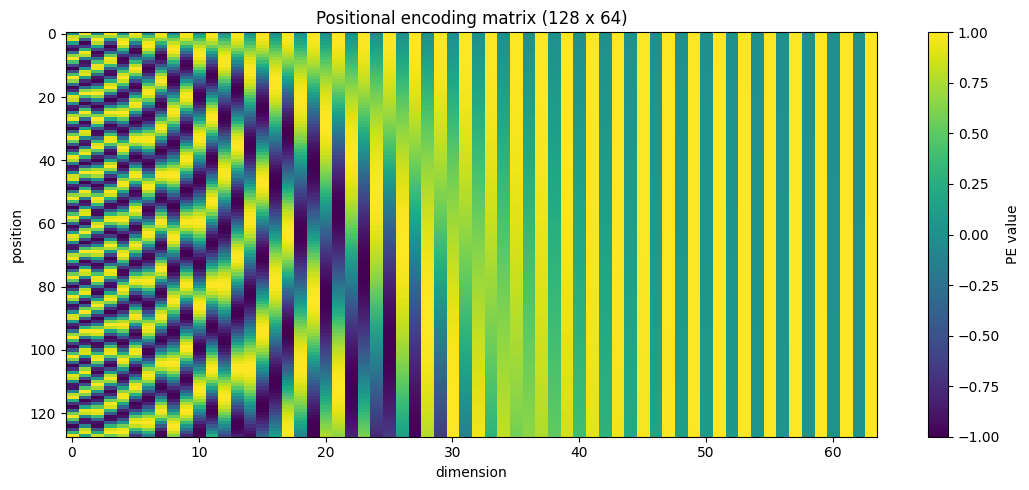

In [10]:
# TODO: build the PositionalEncoding matrix for (max_len=128, d_model=64)
#       and plot it as a heatmap (position on the vertical axis, dimension on
#       the horizontal axis, imshow with aspect='auto')
# TODO: print 'pe[0, :6]' -- you should see 0, 1, 0, 1, ... because
#       sin(0) = 0 and cos(0) = 1; a nice hand-check of the formula

PE = PositionalEncoding(128, D_MODEL)      # max_len = 128, d_model = 64
pe = PE.pe.squeeze(0).numpy()
print("PE matrix shape:", pe.shape)
print("row 0, first 6 dims:", pe[0, :6].round(3).tolist())

plt.figure(figsize=(11, 5))
plt.imshow(pe, aspect="auto", cmap="viridis")
plt.colorbar(label="PE value")
plt.xlabel("dimension")
plt.ylabel("position")
plt.title("Positional encoding matrix (128 x 64)")
plt.tight_layout()
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۵ — بلوک کدگذار ترنسفورمر</h2>
<p style="text-align: right;">
حالا همهٔ قطعات را کنار هم می‌چینیم. هر بلوک کدگذار از یک توجه چندسر، یک شبکهٔ پیش‌خور (FFN) و دو اتصال باقی‌مانده (residual) با نرمال‌سازی تشکیل شده است. نمودار زیر (سلول بعدی، مرجع) مسیر داده را با شکل‌های واقعی تنسورها نشان می‌دهد:
</p>
<p style="text-align: right;">
ورودی <code dir="ltr">(B, T)</code> ← Embedding و Positional Encoding ← <code dir="ltr">(B, T, 64)</code> ← [ توجه چندسر ۴سر با $d_k = 16$ ← Add &amp; Norm ← FFN با بعد پنهان ۲۵۶ و GELU ← Add &amp; Norm ] × 2 ← میانگین‌گیری روی مکان‌های غیرپدینگ ← <code dir="ltr">(B, 64)</code> ← Linear ← <code dir="ltr">(B, 1)</code>.
</p>
<h3 style="text-align: right;">مشخصات کامل معماری (همهٔ اعداد واقعی)</h3>
<ul style="text-align: right;">
<li style="text-align: right;"><code dir="ltr">vocab_size</code> = 70943 (در فاز ۶ روی بخش آموزش ساخته می‌شود و همین عدد است)</li>
<li style="text-align: right;"><code dir="ltr">d_model</code> = 64 ، <code dir="ltr">n_heads</code> = 4 (پس <code dir="ltr">d_k = d_v = 16</code>)</li>
<li style="text-align: right;"><code dir="ltr">d_ff</code> = 256 (یعنی ۴ برابر <code dir="ltr">d_model</code>)</li>
<li style="text-align: right;"><code dir="ltr">n_layers</code> = 2</li>
<li style="text-align: right;"><code dir="ltr">max_len</code> = 128</li>
<li style="text-align: right;"><code dir="ltr">dropout</code> = 0.1</li>
<li style="text-align: right;">تابع فعال‌سازی: GELU</li>
<li style="text-align: right;">جای نرمال‌سازی: <b>Pre-LN</b> یعنی $x + \mathrm{Sublayer}(\mathrm{LayerNorm}(x))$ — در مقیاس کوچک بدون برنامهٔ گرم‌کردن نرخ یادگیری (warmup) پایدارتر است؛ Post-LN معمولاً به warmup نیاز دارد.</li>
</ul>
<h3 style="text-align: right;">وظیفه</h3>
<p style="text-align: right;">
کلاس <code dir="ltr">TransformerEncoderBlock</code> را از ماژول‌های فازهای ۳ و ۴ بسازید: توجه چندسر + باقی‌مانده + LayerNorm + شبکهٔ پیش‌خور + باقی‌مانده + LayerNorm (ترتیب Pre-LN). سپس کلاس <code dir="ltr">TransformerEncoder</code> را بنویسید که <code dir="ltr">n_layers</code> بلوک را روی هم بچیند و علاوه بر خروجی، وزن‌های توجه هر لایه را هم برگرداند (در فاز ۷ برای تصویرسازی لازم است).
</p>
</div>

In [11]:
# Given config (phase 5) - read-only cell; do not edit.
# VOCAB_SIZE is the real number produced by phase 6 (whitespace tokenizer on
# the fixed training split); the rest are the architecture spec of the markdown.
VOCAB_SIZE = 70943
D_FF = 256             # 4 * D_MODEL
N_LAYERS = 2
MAX_LEN = 128
DROPOUT = 0.1
print("architecture spec:",
      "vocab_size =", VOCAB_SIZE,
      "| d_model =", D_MODEL,
      "| n_heads =", N_HEADS,
      "| d_ff =", D_FF,
      "| layers =", N_LAYERS,
      "| max_len =", MAX_LEN,
      "| dropout =", DROPOUT)

architecture spec: vocab_size = 70943 | d_model = 64 | n_heads = 4 | d_ff = 256 | layers = 2 | max_len = 128 | dropout = 0.1


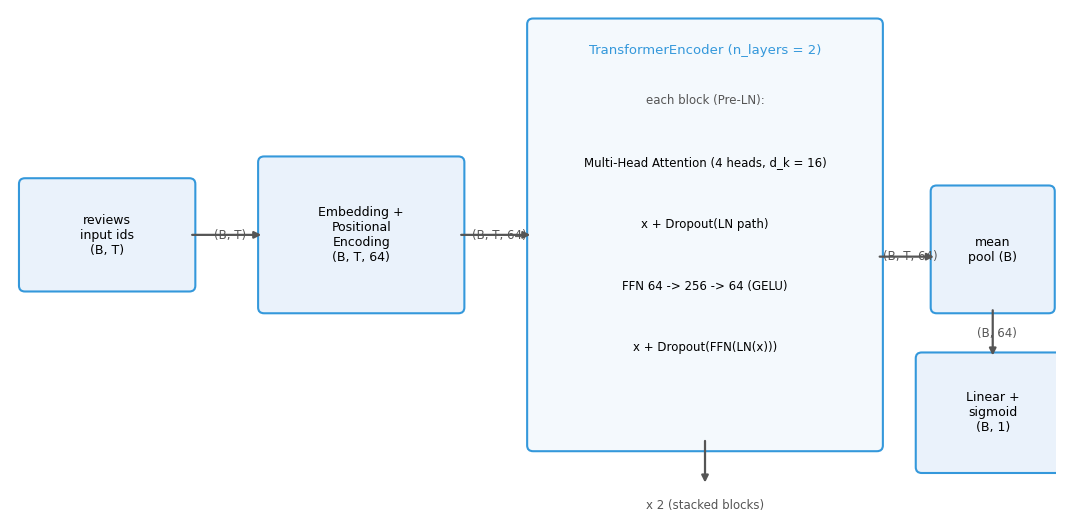

In [12]:
# Given - architecture diagram of this notebook's sentiment model
# (reference; arrows are labelled with the real tensor shapes, B = batch).
fig, ax = plt.subplots(figsize=(13.5, 6.6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis("off")


def box(x, y, w, h, text, fc="#eaf2fb", ec="#3498db", fs=10):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                                fc=fc, ec=ec, lw=1.5))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs)


def fwd(x1, y1, x2, y2, label=""):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color="#555555", lw=1.6))
    if label:
        ax.text((x1 + x2) / 2 + 0.05, (y1 + y2) / 2, label, ha="center",
                va="center", fontsize=8.5, color="#555555")


box(0.2, 3.2, 2.2, 1.4, """reviews
input ids
(B, T)""", fs=9)
fwd(2.4, 3.9, 3.4, 3.9, "(B, T)")
box(3.4, 2.9, 2.6, 2.0, """Embedding +
Positional
Encoding
(B, T, 64)""", fs=9)
fwd(6.0, 3.9, 7.0, 3.9, "(B, T, 64)")
box(7.0, 1.0, 4.6, 5.8, "", fc="#f4f9fd")
ax.text(9.3, 6.4, "TransformerEncoder (n_layers = 2)", ha="center",
        fontsize=9.5, color="#3498db")
ax.text(9.3, 5.7, "each block (Pre-LN):", ha="center", fontsize=8.5,
        color="#555555")
for i, line in enumerate(["Multi-Head Attention (4 heads, d_k = 16)",
                          "x + Dropout(LN path)",
                          "FFN 64 -> 256 -> 64 (GELU)",
                          "x + Dropout(FFN(LN(x)))"]):
    ax.text(9.3, 4.85 - 0.85 * i, line, ha="center", fontsize=8.5)
fwd(9.3, 1.1, 9.3, 0.45)
ax.text(9.3, 0.12, "x 2 (stacked blocks)", ha="center", fontsize=8.5,
        color="#555555")
fwd(11.6, 3.6, 12.4, 3.6, "(B, T, 64)")
box(12.4, 2.9, 1.5, 1.6, """mean
pool (B)""", fs=9)
fwd(13.15, 2.9, 13.15, 2.2, "(B, 64)")
box(12.2, 0.7, 1.9, 1.5, """Linear +
sigmoid
(B, 1)""", fs=9)
plt.show()

In [13]:
# TODO: implement 'TransformerEncoderBlock(nn.Module)' (Pre-LN):
#       MHA (phase 3) + residual + LayerNorm + FFN + residual + LayerNorm,
#       using the order  x + Sublayer(LayerNorm(x)); GELU activation,
#       dropout after every sublayer; returns (x, attn)
# TODO: implement 'TransformerEncoder(nn.Module)': stack n_layers blocks,
#       return (x, attns) where attns is the list of per-layer attention


class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out, attn = self.attn(self.ln1(x), mask=mask)
        x = x + self.dropout(attn_out)
        x = x + self.dropout(self.ffn(self.ln2(x)))
        return x, attn


class TransformerEncoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList(
            [TransformerEncoderBlock(d_model, n_heads, d_ff, dropout)
             for _ in range(n_layers)])

    def forward(self, x, mask=None):
        attns = []
        for layer in self.layers:
            x, attn = layer(x, mask=mask)
            attns.append(attn)
        return x, attns

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right; color: #3498db;">بحث کنید</h3><p style="text-align: right;">تفاوت Pre-LN و Post-LN در پایداری آموزش چیست؟ چرا در مقیاس کوچک و بدون warmup، Pre-LN پایدارتر است؟</p><p style="text-align: right;"><b>پاسخ پیشنهادی (برای مقایسه با پاسخ خودتان):</b></p><p style="text-align: right;">در Post-LN نرمال‌سازی بعد از جمع باقی‌مانده قرار می‌گیرد: <code dir='ltr'>x + LN(Sublayer(x))</code>. در این حالت گرادیان برای رسیدن به لایه‌های پایین باید از لایه‌های نرمال‌ساز عبور کند و بزرگی فعال‌سازی‌ها در طول شبکه کنترل دقیقی ندارد؛ به همین دلیل آموزش Post-LN حساس است و عملاً به warmup (گرم‌کردن نرخ یادگیری) و تنظیم دقیق نرخ یادگیری نیاز دارد. در Pre-LN ابتدا ورودی نرمال می‌شود و زیرلایه روی نسخهٔ نرمال‌شده اجرا می‌شود: <code dir='ltr'>x + Sublayer(LN(x))</code>. در نتیجه مسیر باقی‌مانده یک مسیر همانیِ مستقیم است و مقیاس فعال‌سازی‌ها در هر بلوک کنترل می‌شود؛ به همین دلیل در مقیاس کوچک و بدون warmup پایدارتر است و با نرخ یادگیری ثابت کار می‌کند (انتخاب همین دفترچه). معاوضهٔ شناخته‌شده: Post-LNِ خوب تنظیم‌شده گاهی دقت نهاییِ کمی بالاتر می‌دهد، اما بی‌ثباتی آن در تمرین‌های کوچک به‌صرفه نیست.</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۶ — خط لولهٔ داده: IMDb و یک توکن‌ساز ساده</h2>
<p style="text-align: right;">
مجموعه‌دادهٔ IMDb شامل نظرات فیلم با برچسب مثبت/منفی است (طبقه‌بندی دودویی احساسات). از کل نظرات IMDb (بخش‌های <code dir="ltr">train</code> و <code dir="ltr">test</code>) با یک جابه‌جایی تصادفیِ سیددار، 15000 نظر برای آموزش و 1500 نظر برای اعتبارسنجی برمی‌داریم؛ این اعداد ثابت هستند و همهٔ اجراها (از جمله راه‌حل مرجع) از همین زیرمجموعه استفاده می‌کنند.
</p>
<p style="text-align: right;">
توکن‌ساز عمداً ساده است — <b>فقط</b> جداسازی با فاصلهٔ سفید و کوچک‌سازی حروف، به‌علاوهٔ حذف علائم نگارشی پایه؛ هیچ توکن‌ساز زیرواژه‌ای (BPE) استفاده نمی‌شود. واژگان (vocab) از <b>فقط</b> بخش آموزش ساخته می‌شود و نشانه‌های <code dir="ltr">&lt;pad&gt;</code> و <code dir="ltr">&lt;unk&gt;</code> را دارد. نتیجهٔ نهایی <code dir="ltr">vocab_size = 70943</code> است — همان عددی که در فاز ۵ اعلام شد.
</p>
<p style="text-align: right;">
همهٔ دنباله‌ها به طول <code dir="ltr">max_len = 128</code> کوتاه یا با <code dir="ltr">&lt;pad&gt;</code> پر می‌شوند. یک <b>ماسک پدینگ</b> می‌سازیم و آن را (الف) در توجه به‌کار می‌بریم تا جایگاه‌های پرشده وزن نگیرند و (ب) در میانگین‌گیری (mean pooling) فاز ۷ حساب نشوند.
</p>
<p style="text-align: right; color: var(--jp-ui-font-color2, #6b7280);">
نکتهٔ بدون نشتی: تقسیم آموزش/اعتبارسنجی <b>پیش از</b> ساخت واژگان انجام شده است؛ یعنی واژگان فقط روی بخش آموزش ساخته می‌شود و هیچ نظری از بخش اعتبارسنجی در آن دیده نمی‌شود.
</p>
</div>

In [14]:
# Given - read-only cell; do not edit.
# Download + load IMDB once (the ~80 MB tarball is cached in ./data, and the
# parsed reviews are cached in data/imdb_texts.pkl), then pick the fixed
# seeded train/val subsets. The split happens BEFORE the vocabulary is built,
# so the vocab never sees a validation review.
N_TRAIN = 15000
N_VAL = 1500


def load_imdb():
    cache = DATA_DIR / "imdb_texts.pkl"
    if cache.exists():
        with open(cache, "rb") as f:
            return pickle.load(f)
    if not (DATA_DIR / "aclImdb").exists():
        if not (DATA_DIR / "aclImdb_v1.tar.gz").exists():
            print(f"downloading IMDB from {IMDB_URL} (one time, ~80 MB) ...")
            urllib.request.urlretrieve(IMDB_URL, DATA_DIR / "aclImdb_v1.tar.gz")
        with tarfile.open(DATA_DIR / "aclImdb_v1.tar.gz", "r:gz") as tar:
            tar.extractall(DATA_DIR)
    reviews = []
    for split in ("train", "test"):
        for label, sub in ((1, "pos"), (0, "neg")):
            folder = DATA_DIR / "aclImdb" / split / sub
            for fname in sorted(folder.iterdir()):
                if fname.suffix == ".txt":
                    reviews.append((fname.read_text(encoding="utf-8"), label))
    with open(cache, "wb") as f:
        pickle.dump(reviews, f)
    return reviews


reviews = load_imdb()
print("loaded", len(reviews), "reviews (train + test splits of IMDB)")

order = np.random.RandomState(SEED).permutation(len(reviews))
train_idx = order[:N_TRAIN]
val_idx = order[N_TRAIN:N_TRAIN + N_VAL]
TRAIN_TEXT = [reviews[i][0] for i in train_idx]
TRAIN_LABELS = torch.tensor([reviews[i][1] for i in train_idx], dtype=torch.long)
VAL_TEXT = [reviews[i][0] for i in val_idx]
VAL_LABELS = torch.tensor([reviews[i][1] for i in val_idx], dtype=torch.long)
print(f"train reviews: {len(TRAIN_TEXT)} | val reviews: {len(VAL_TEXT)}")

loaded 50000 reviews (train + test splits of IMDB)
train reviews: 15000 | val reviews: 1500


In [15]:
# TODO: implement 'tokenize(text)': lowercase the text, strip basic
#       punctuation (keep letters, digits and apostrophes), split on whitespace
# TODO: print the first 20 tokens and the token count of TRAIN_TEXT[0]


def tokenize(text):
    text = re.sub(r"[^a-z0-9\s']", " ", text.lower())
    return text.split()


print("first 20 tokens of review 0:", tokenize(TRAIN_TEXT[0])[:20])
print("token count of review 0:", len(tokenize(TRAIN_TEXT[0])))

first 20 tokens of review 0: ['when', 'i', 'first', 'saw', 'the', 'ad', 'for', 'this', 'i', 'was', 'like', "'oh", 'here', 'we', 'go', "he's", 'done', 'high', 'school', 'musical']
token count of review 0: 125


In [16]:
# TODO: implement 'build_vocab(sentences)' -> word->id dict with
#       '<pad>' = 0 and '<unk>' = 1 (use PAD_IDX / UNK_IDX)
# TODO: implement 'encode(sentences, vocab, max_len)' -> long tensor (N, max_len)
#       padded with <pad>; sequences longer than max_len are truncated; words
#       outside the vocab map to <unk>
# TODO: build the vocab on TRAIN_TEXT only, print the resulting vocab_size and
#       compare it with VOCAB_SIZE declared in phase 5


def build_vocab(sentences):
    vocab = {"<pad>": PAD_IDX, "<unk>": UNK_IDX}
    for s in sentences:
        for w in tokenize(s):
            if w not in vocab:
                vocab[w] = len(vocab)
    return vocab


def encode(sentences, vocab, max_len):
    N = len(sentences)
    X = torch.full((N, max_len), PAD_IDX, dtype=torch.long)
    for r, s in enumerate(sentences):
        ids = [vocab.get(w, UNK_IDX) for w in tokenize(s)][:max_len]
        X[r, : len(ids)] = torch.tensor(ids, dtype=torch.long)
    return X


VOCAB = build_vocab(TRAIN_TEXT)
print("vocab_size =", len(VOCAB), "| declared in phase 5:", VOCAB_SIZE)
assert len(VOCAB) == VOCAB_SIZE, "vocab size does not match the phase-5 spec" 

vocab_size = 70943 | declared in phase 5: 70943


In [17]:
# TODO: encode the train/val reviews with max_len = MAX_LEN, build the padding
#       masks: True where the token IS <pad> (the attention of phase 7 hides
#       those positions; use ~mask for the valid positions in the mean pooling)
# TODO: print the shapes of X_train / X_val, the positive-class ratio of the
#       validation split (~0.5), and the first 80 characters of TRAIN_TEXT[0]
#       together with its label and its real (unpadded) token count

X_train = encode(TRAIN_TEXT, VOCAB, MAX_LEN)
X_val = encode(VAL_TEXT, VOCAB, MAX_LEN)
y_train = TRAIN_LABELS
y_val = VAL_LABELS
mask_train = X_train == PAD_IDX
mask_val = X_val == PAD_IDX

print("X_train:", tuple(X_train.shape), "| X_val:", tuple(X_val.shape))
print("val positive-class ratio:", y_val.float().mean().item())
print("review 0:", TRAIN_TEXT[0][:80])
print("label of review 0:", y_train[0].item(), "| real token count:",
      (~mask_train[0]).sum().item())

X_train: (15000, 128) | X_val: (1500, 128)
val positive-class ratio: 0.49799999594688416
review 0: When I first saw the ad for this, I was like 'Oh here we go. He's done High Scho
label of review 0: 1 | real token count: 125


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۷ — مدل کامل، آموزش و توجه واقعی</h2>
<p style="text-align: right;">
مدل کامل این دفترچه:
</p>
<ul style="text-align: right;">
<li style="text-align: right;"><code dir="ltr">Embedding(vocab_size, d_model=64)</code></li>
<li style="text-align: right;"><code dir="ltr">+ PositionalEncoding</code> (فاز ۴)</li>
<li style="text-align: right;"><code dir="ltr">TransformerEncoder</code> با ۲ لایه (فاز ۵)</li>
<li style="text-align: right;">میانگین‌گیری روی مکان‌های غیرپدینگ ← <code dir="ltr">Linear(64, 1)</code> ← سیگموئید</li>
</ul>
<p style="text-align: right;">
فراپارامترهای آموزش (دقیقاً همین‌ها): <code dir="ltr">batch_size = 32</code>، بهینه‌ساز <code dir="ltr">AdamW</code> با <code dir="ltr">lr = 3e-4</code>، <code dir="ltr">epochs = 5</code> و تابع خطای <code dir="ltr">BCEWithLogitsLoss</code>. اجرای کامل روی CPU معمولی حدود 10 دقیقه طول می‌کشد.
</p>
<h3 style="text-align: right;">توجه واقعی (بخش الزامی)</h3>
<p style="text-align: right;">
پس از آموزش، <b>دو نظر واقعی کوتاه از مجموعهٔ اعتبارسنجی</b> را انتخاب کنید و با مدل آموزش‌دیده‌تان وزن‌های توجه را بگیرید: گرمای هر ۴ سر لایهٔ ۰ را با کلمات واقعیِ توکن‌شده روی هر دو محور رسم کنید (هر سر یک زیرنمودار و برای هر نظر یک شکل). انتظار نداشته باشید که همهٔ سرها الگوی شفافی بدهند — در این مقیاس و با این تعداد epoch، نویزی بودن بعضی سرها کاملاً طبیعی است و خودش یک بحث است؛ چیزی را پنهان یا «چریک‌پیک» نکنید.
</p>
<h3 style="text-align: right;">وظیفه</h3>
<p style="text-align: right;">
کلاس <code dir="ltr">SentimentTransformer</code> را بنویسید (با متد <code dir="ltr">attention_weights</code> برای گرفتن وزن‌های توجه هر لایه)، مدل را با فراپارامترهای فاز ۵ بسازید و تعداد پارامترها را چاپ کنید. سپس <code dir="ltr">train_model</code> را پیاده‌سازی کنید، مدل را آموزش دهید، منحنی خطای آموزش و دقت اعتبارسنجی را رسم کنید و در پایان تصویرسازی توجه واقعی را انجام دهید.
</p>
</div>

In [18]:
# TODO: implement 'SentimentTransformer(nn.Module)' (phase 7):
#       Embedding(vocab_size, d_model) -> + PositionalEncoding (phase 4)
#       -> TransformerEncoder (phase 5) -> mean pooling over non-pad
#       positions -> Linear(d_model, 1) logit
#       forward(input_ids, mask) -> logits (B, 1)
#       attention_weights(input_ids, mask) -> list of per-layer attns
#       (B, n_heads, T, T), used by the real attention visualization
# TODO: build the model with the phase-5 hyperparameters after
#       torch.manual_seed(SEED) and print its parameter count


class SentimentTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, max_len, dropout):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos = PositionalEncoding(max_len, d_model)
        self.encoder = TransformerEncoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.head = nn.Linear(d_model, 1)

    def forward(self, input_ids, mask):
        x = self.pos(self.embed(input_ids))                  # (B, T, d_model)
        x, _ = self.encoder(x, mask=mask)                    # (B, T, d_model)
        valid = ~mask                                        # True = real token
        lengths = valid.sum(dim=1, keepdim=True).clamp(min=1)
        x = (x * valid.unsqueeze(-1)).sum(dim=1) / lengths   # (B, d_model)
        return self.head(x)                                  # (B, 1)

    def attention_weights(self, input_ids, mask):
        x = self.pos(self.embed(input_ids))
        _, attns = self.encoder(x, mask=mask)
        return attns


torch.manual_seed(SEED)
model = SentimentTransformer(len(VOCAB), D_MODEL, N_HEADS, D_FF, N_LAYERS, MAX_LEN, DROPOUT)
n_params = sum(p.numel() for p in model.parameters())
print("trainable parameters:", n_params)

trainable parameters: 4640385


epoch  1: train loss 0.6348 | val acc 0.6747


epoch  2: train loss 0.5163 | val acc 0.7587


epoch  3: train loss 0.4513 | val acc 0.7833


epoch  4: train loss 0.3999 | val acc 0.8047


epoch  5: train loss 0.3533 | val acc 0.8200


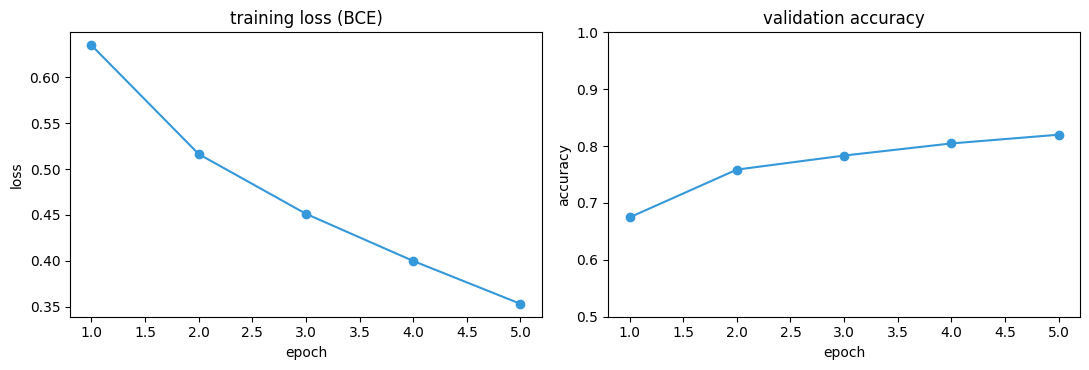

In [19]:
# TODO: implement 'train_model(model, X_train, y_train, mask_train,
#       X_val, y_val, mask_val, epochs=5, batch_size=32, lr=3e-4, seed=SEED)'
#       -> (train_losses, val_accs) with AdamW + BCEWithLogitsLoss;
#       model.train() during training and model.eval() + torch.no_grad()
#       when computing the per-epoch validation accuracy
# TODO: train the model, print the losses / val accuracies, and plot both
#       curves (one figure, two subplots)

BATCH_SIZE = 32
LR = 3e-4
EPOCHS = 5


def train_model(model, X_train, y_train, mask_train, X_val, y_val, mask_val,
                epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, seed=SEED):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    train_losses, val_accs = [], []
    for epoch in range(1, epochs + 1):
        model.train()
        order = torch.randperm(X_train.size(0),
                               generator=torch.Generator().manual_seed(seed + epoch))
        epoch_loss = []
        for s in range(0, X_train.size(0), batch_size):
            b = order[s:s + batch_size]
            opt.zero_grad()
            logits = model(X_train[b], mask_train[b])
            loss = loss_fn(logits, y_train[b].float().view(-1, 1))
            loss.backward()
            opt.step()
            epoch_loss.append(loss.item())
        model.eval()
        with torch.no_grad():
            logits = model(X_val, mask_val)
            preds = (torch.sigmoid(logits).squeeze(1) >= 0.5).long()
            val_acc = (preds == y_val).float().mean().item()
        tl = float(np.mean(epoch_loss))
        train_losses.append(tl)
        val_accs.append(val_acc)
        print(f"epoch {epoch:2d}: train loss {tl:.4f} | val acc {val_acc:.4f}")
    return train_losses, val_accs


train_losses, val_accs = train_model(model, X_train, y_train, mask_train,
                                     X_val, y_val, mask_val)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(range(1, EPOCHS + 1), train_losses, marker="o", color="#3498db")
axes[0].set_title("training loss (BCE)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[1].plot(range(1, EPOCHS + 1), val_accs, marker="o", color="#3498db")
axes[1].set_title("validation accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

chosen validation reviews:
  [0] label=0 | Something does not work in this movie. There are absolutely no energies between the actors. In fact,
  [1] label=0 | Giant crabs cursing in Japanese? What was in that drink? A terrible movie, but laughable. I love the
review 0: predicted P(positive) = 0.005, tokens = 33


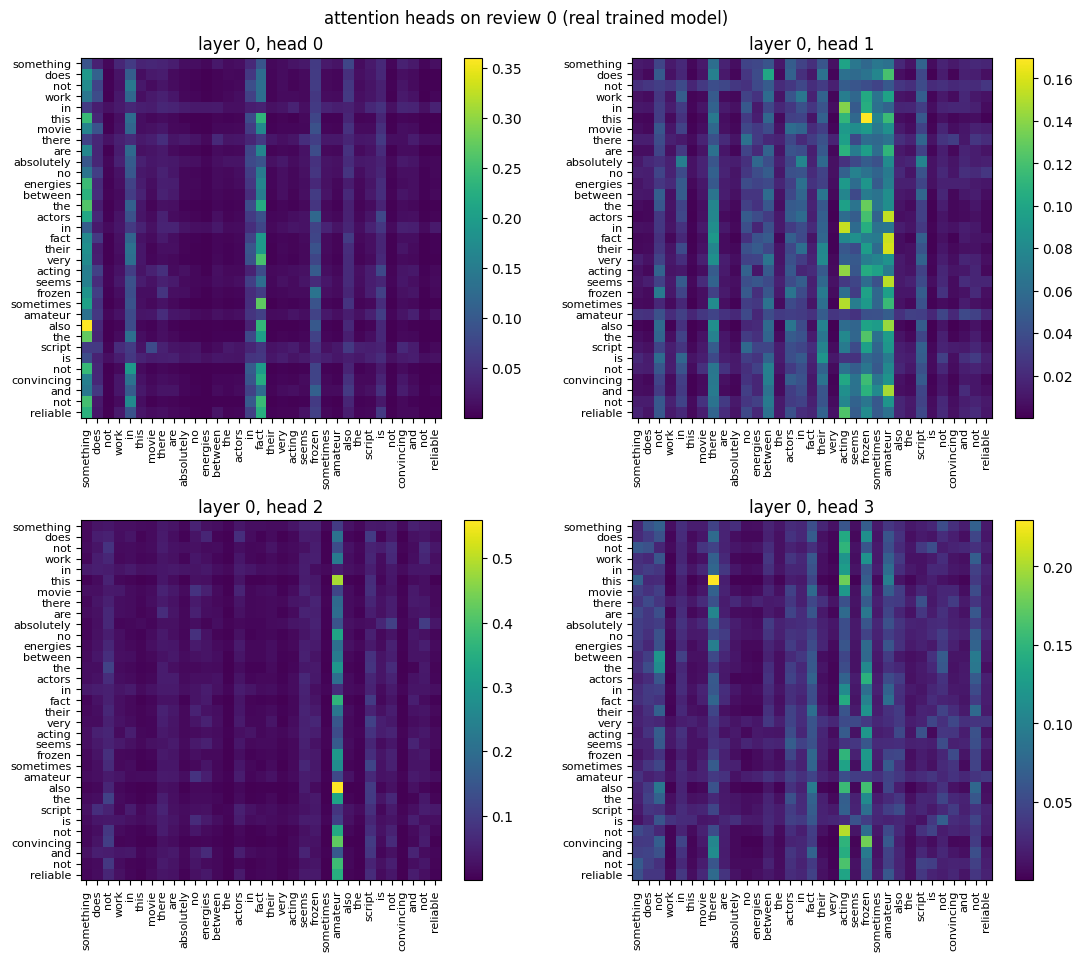

review 1: predicted P(positive) = 0.001, tokens = 31


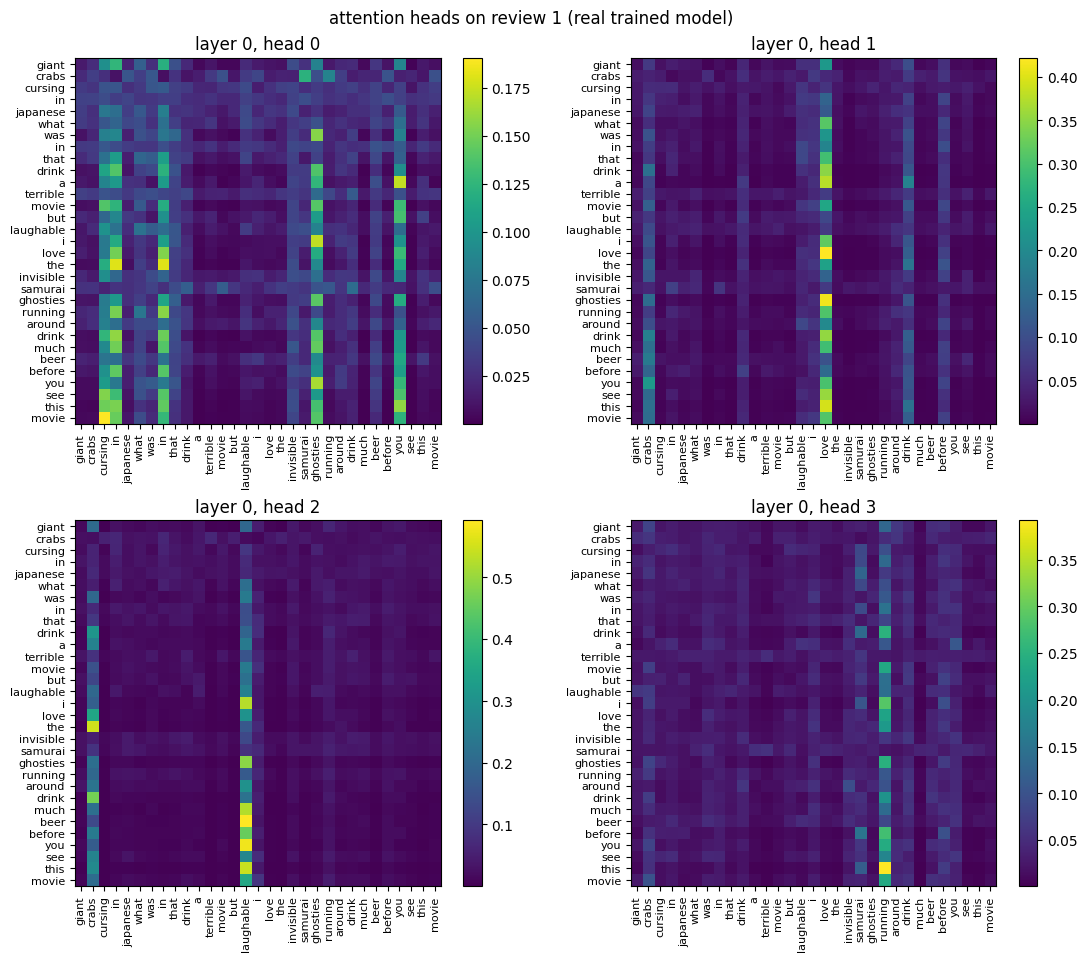

In [20]:
# TODO: pick 2 short real validation reviews (e.g. the first two with at
#       most 36 tokens) and print their texts
# TODO: run each through the trained model and plot all 4 heads of layer 0
#       (one figure per review, 2x2 subplots), with the actual tokenized words
#       on both axes; also print the model's predicted P(positive) per review
# TODO (look, don't cherry-pick): some heads will look structured, others
#       noisy; report what you actually see in the discussion cell

def pick_short(candidates, max_tokens=36):
    short = [t for t in candidates if len(tokenize(t)) <= max_tokens]
    return short[:2]


REVIEWS = pick_short(VAL_TEXT)
print("chosen validation reviews:")
for i, r in enumerate(REVIEWS):
    print(f"  [{i}] label={VAL_LABELS[i].item()} | {r[:100]}")


def review_to_ids(text, vocab):
    ids = [vocab.get(w, UNK_IDX) for w in tokenize(text)]
    return torch.tensor(ids, dtype=torch.long).unsqueeze(0)      # (1, T)


model.eval()
for i, r in enumerate(REVIEWS):
    ids = review_to_ids(r, VOCAB)
    none_pad = torch.zeros_like(ids, dtype=torch.bool)          # nothing to hide
    with torch.no_grad():
        attns = model.attention_weights(ids, none_pad)
        p = torch.sigmoid(model(ids, none_pad)).item()
    tokens = tokenize(r)
    A = attns[0][0].numpy()                                      # layer 0: (H, T, T)
    print(f"review {i}: predicted P(positive) = {p:.3f}, tokens = {len(tokens)}")
    fig, axes = plt.subplots(2, 2, figsize=(11, 9.5), layout="constrained")
    for h in range(N_HEADS):
        ax = axes[h // 2][h % 2]
        im = ax.imshow(A[h], cmap="viridis")
        ax.set_xticks(range(len(tokens)))
        ax.set_xticklabels(tokens, rotation=90, fontsize=8)
        ax.set_yticks(range(len(tokens)))
        ax.set_yticklabels(tokens, fontsize=8)
        ax.set_title(f"layer 0, head {h}")
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(f"attention heads on review {i} (real trained model)")
    plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right; color: #3498db;">بحث کنید</h3><p style="text-align: right;">الگوهای توجه واقعی مدل شما تا چه حد قابل تفسیر بودند؟ آیا سرها تخصص متفاوتی نشان دادند یا نویزی به نظر می‌رسیدند؟ چرا ممکن است چنین باشد؟ (به اندازهٔ مدل، تعداد epochها و توکن‌ساز ساده فکر کنید.)</p><p style="text-align: right;"><b>پاسخ پیشنهادی (برای مقایسه با پاسخ خودتان):</b></p><p style="text-align: right;">در این مقیاس انتظار داریم بیشتر سرها توزیع پخش و نویزی داشته باشند و فقط بعضی سرها تمرکز نسبی — مثلاً روی چند نشانهٔ خاص یا همسایگی‌ها — نشان دهند. دلایل اصلی: (۱) مدل کوچک است ($d_{model} = 64$، دو لایه) و فقط ۵ epoch آموزش دیده؛ سرها فرصت کافی برای تخصصی‌شدن نداشته‌اند. (۲) هدف مدل فقط طبقه‌بندی با میانگین‌گیری نهایی است؛ مدل هیچ فشاری برای تولید توجه «خوانا» ندارد — توجه یک ابزار محاسباتی است، نه یک توضیح‌دهنده. (۳) توکن‌ساز سادهٔ جداسازی با فاصله، کلمات کم‌فراوان را به نشانهٔ ناشناس (<code dir='ltr'>&lt;unk&gt;</code>) می‌برد و وزن‌ها را به سمت کلمات پرتکرار و کم‌ساختار می‌کشد. (۴) dropout و نوسان یک نمونهٔ تنها، تصویر را نویزی می‌کند. نکتهٔ روش‌شناختی: فقط همان را گزارش کنیم که می‌بینیم و برای قضاوت دربارهٔ یک سر، چند جمله را با هم ببینیم؛ یک الگوی اتفاقی در یک جمله «تفسیر» نیست.</p></div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="text-align: right; color: #3498db;">فاز ۸ — ارزیابی: نتیجهٔ کار خودتان را ببینید</h2>
<p style="text-align: right;">
سلول زیر مدل آموزش‌دیدهٔ شما را روی مجموعهٔ اعتبارسنجی ارزیابی می‌کند. معیار اصلی <b>دقت</b> (accuracy) و در کنار آن <b>F1</b> گزارش می‌شود؛ چون توزیع کلاس‌ها در این زیرمجموعه تقریباً متوازن است، دقت معیار کافی و معتبری است.
</p>
<p style="text-align: right;">
مقدار مورد انتظار راه‌حل مرجع: دقت <b dir="ltr">≈ 0.0</b> و F1 <b dir="ltr">≈ 0.0</b> روی مجموعهٔ اعتبارسنجی.
</p>
<p style="text-align: right; color: var(--jp-ui-font-color2, #6b7280);">
خروجی سلول مرجع زیر (که اجرا نمی‌کنید) نتایج واقعی راه‌حل طراح را نشان می‌دهد: همان اعداد، منحنی‌های آموزش و گرمای توجه واقعی — نتیجهٔ خودتان را با آن مقایسه کنید. اختلاف کوچک (چند صدم) طبیعی است؛ اگر اختلاف بزرگ بود سلول‌های فاز ۷ را بازبینی کنید.
</p>
</div>

In [21]:
# Evaluation cell - run it and compare with the reference value
def evaluate(model, X, y, mask):
    model.eval()
    with torch.no_grad():
        logits = model(X, mask)
        preds = (torch.sigmoid(logits).squeeze(1) >= 0.5).long()
    acc = (preds == y).float().mean().item()
    tp = ((preds == 1) & (y == 1)).sum().item()
    fp = ((preds == 1) & (y == 0)).sum().item()
    fn = ((preds == 0) & (y == 1)).sum().item()
    prec = tp / (tp + fp) if tp + fp > 0 else 0.0
    rec = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0.0
    print(f"validation accuracy: {acc:.4f}")
    print(f"validation F1:       {f1:.4f}  (precision {prec:.3f}, recall {rec:.3f})")
    print(f"positive-class ratio: {y.float().mean().item():.3f}")
    return acc, f1


val_acc, val_f1 = evaluate(model, X_val, y_val, mask_val)

validation accuracy: 0.8200
validation F1:       0.8226  (precision 0.808, recall 0.838)
positive-class ratio: 0.498


reference solution - final evaluation:
validation accuracy: 0.8200
validation F1:       0.8226  (precision 0.808, recall 0.838)
positive-class ratio: 0.498


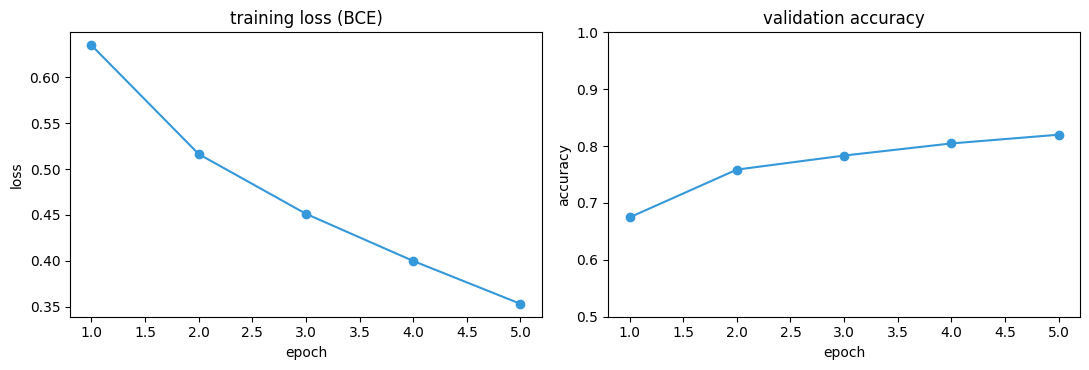

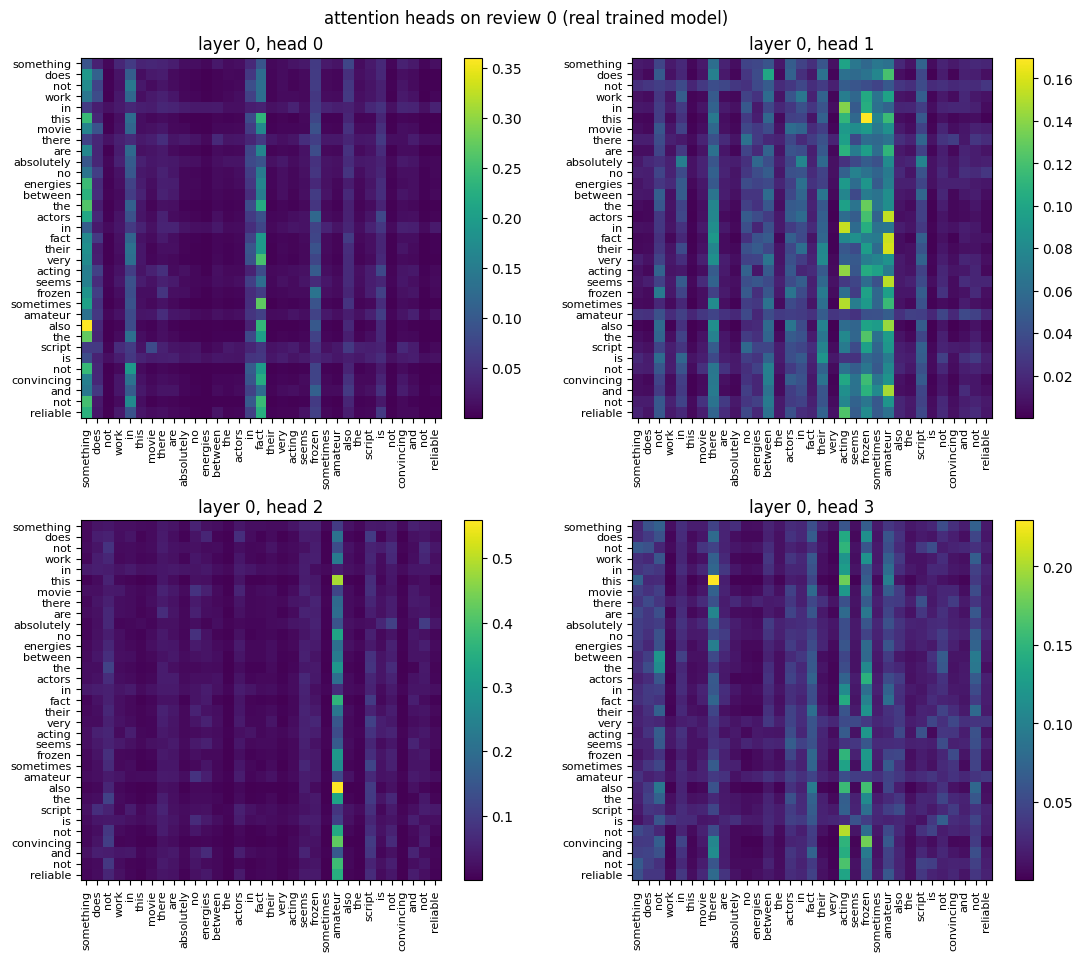

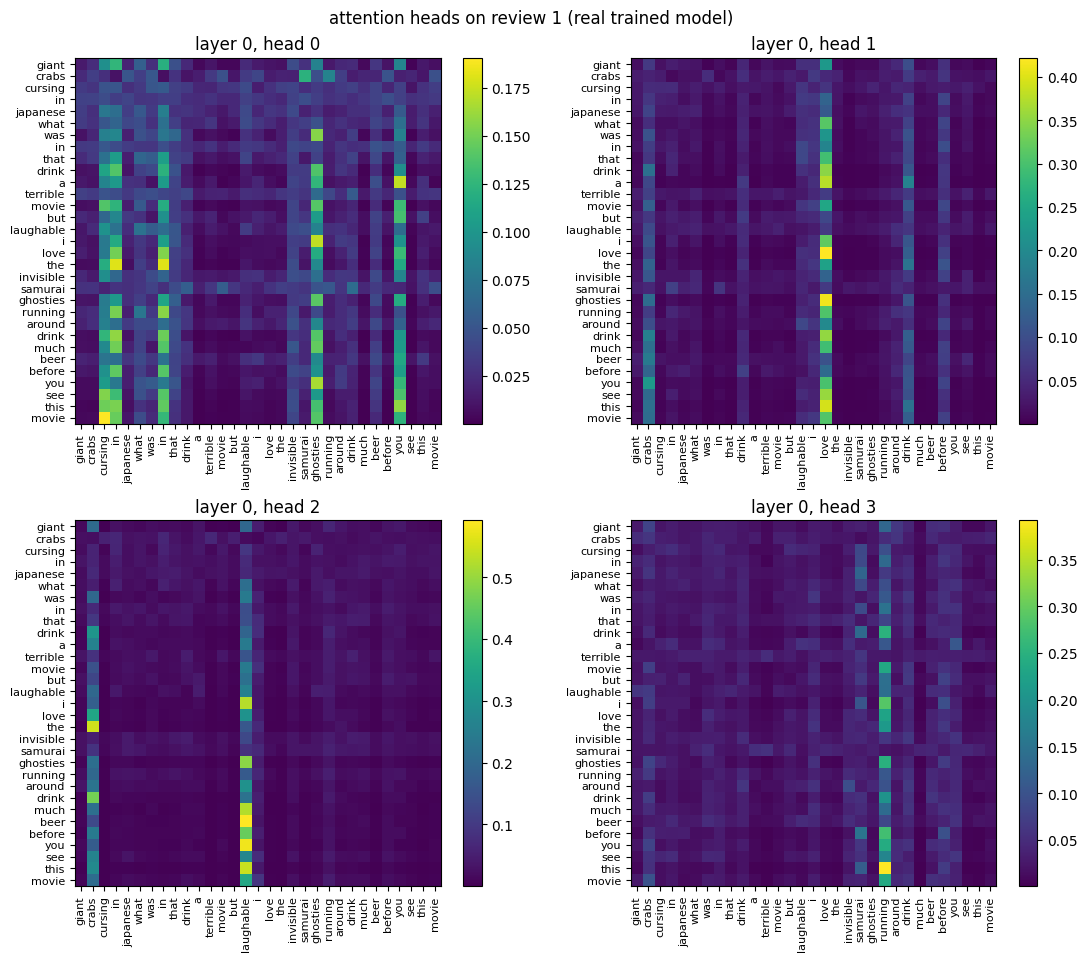

In [ ]:
# Reference cell - do NOT run it (kept for comparison only)
# Designer: real output of the reference solution after a full end-to-end run:
#   1) evaluation metrics on the validation split,
#   2) training loss / validation accuracy curves (5 epochs),
#   3) real attention heatmaps (all 4 heads of layer 0) of the trained model
#      on two real validation reviews.

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;"><h3 style="text-align: right; color: #3498db;">بحث کنید</h3><p style="text-align: right;">اگر <code dir="ltr">max_len</code> را کاهش دهیم چه اتفاقی برای دقت و سرعت آموزش می‌افتد؟ (به‌صورت تجربی هم قابل آزمایش است: <code dir="ltr">MAX_LEN = 64</code> را امتحان کنید.)</p><p style="text-align: right;"><b>پاسخ پیشنهادی (برای مقایسه با پاسخ خودتان):</b></p><p style="text-align: right;">دو اثر داریم. (۱) سرعت: هزینهٔ توجه با طول دنباله به‌صورت درجه دوم رشد می‌کند ($O(T^2)$ در هر سر)، پس با نصف شدن طول (از ۱۲۸ به ۶۴) هزینهٔ بخش توجه تقریباً یک‌چهارم می‌شود و زمان هر epoch به‌طور محسوس کم می‌شود. (۲) دقت: نظراتِ بلندتر از حد مجاز از انتها کوتاه می‌شوند و اطلاعاتِ ادامهٔ نظر (مثل جمع‌بندی پایانی) از دست می‌رود. در IMDb بسیاری از نظرات بلند هستند، اما چون احساسات اغلب در همان ابتدای نظر مشخص می‌شود، افت دقت ممکن است کوچک باشد — برای همین این آزمایش تجربی (مثلاً <code dir='ltr'>MAX_LEN = 64</code> و مقایسه با دقت مرجع ۰٫۸۲) پیشنهاد شده است. نکتهٔ فنی: تغییر <code dir='ltr'>MAX_LEN</code> باید با بازسازی تنسورها و ماسک‌ها در فاز ۶ همراه شود و روی <code dir='ltr'>vocab_size</code> اثری ندارد، چون واژگان مستقل از طول دنباله ساخته می‌شود.</p></div>